# 05 - Analyse

Diagnostics on the two HGBR regression models, on the **primary 2019 test set** (the headline split from notebook 04; the 2020+ COVID era is held out as a separate stress block):
* Per-city predicted vs observed time series.
* Residual distribution.
* SHAP global feature importance (TreeExplainer on HGBR).
* Top-N feature shortlist persisted as `data/output/models/top_features_*.json` -- consumed by the Streamlit UI to pick which features to expose as sliders.

In [2]:
import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_absolute_error

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "data").exists() and REPO_ROOT.parent != REPO_ROOT:
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

DATA = REPO_ROOT / "data"
PROC = DATA / "processed"
OUT  = DATA / "output" / "models"

df = pd.read_csv(PROC / "regression_modeling_table.csv", parse_dates=["date"])
feature_cols = json.loads((OUT / "feature_columns.json").read_text())
cases_model  = joblib.load(OUT / "cases_hgbr.joblib")
deaths_model = joblib.load(OUT / "deaths_hgbr.joblib")
metrics = json.loads((OUT / "metrics.json").read_text())

# adm3_pcode -> human-readable city name (e.g. "PH137603000" -> "City of Muntinlupa"), for plot labels.
city_names = (
    pd.read_csv(DATA / "location.csv")[["adm3_pcode", "adm3_en"]]
    .drop_duplicates("adm3_pcode")
    .set_index("adm3_pcode")["adm3_en"]
    .to_dict()
)

lag_cols = [c for c in feature_cols if any(c.endswith(f"_lag{k}wk") for k in [1, 2, 3, 4])]
df = df.dropna(subset=lag_cols).reset_index(drop=True)
df["year"] = df["date"].dt.year
# Diagnostics run on the primary (2019) test set — the same headline split as notebook 04.
# 2020+ is the COVID-era stress block; metrics.json["stress_2020plus"] reports it separately.
test = df[df["year"] == 2019].copy()
test["pred_cases"]  = cases_model.predict(test[feature_cols])
test["pred_deaths"] = deaths_model.predict(test[feature_cols])
test["resid_cases"]  = test["all_cause_cases"]  - test["pred_cases"]
test["resid_deaths"] = test["all_cause_deaths"] - test["pred_deaths"]
print("test rows (2019):", len(test))

test rows (2019): 624


## 1. Per-city predicted vs observed

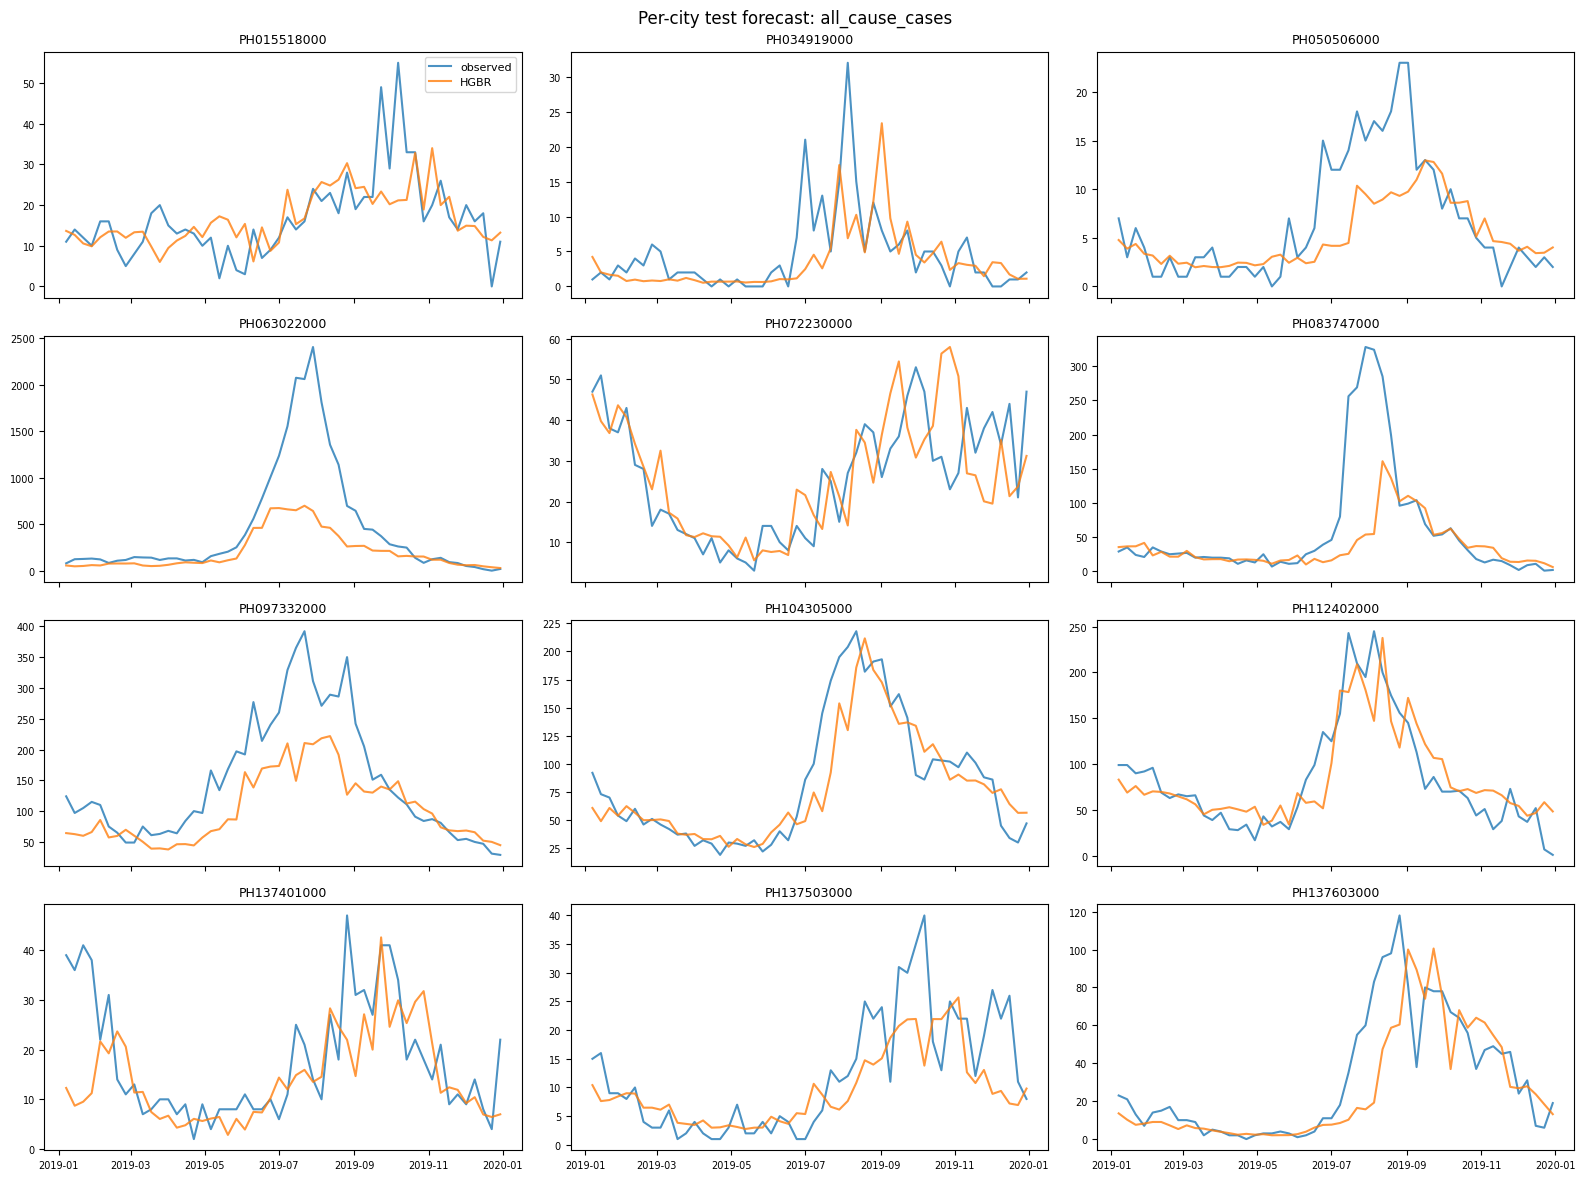

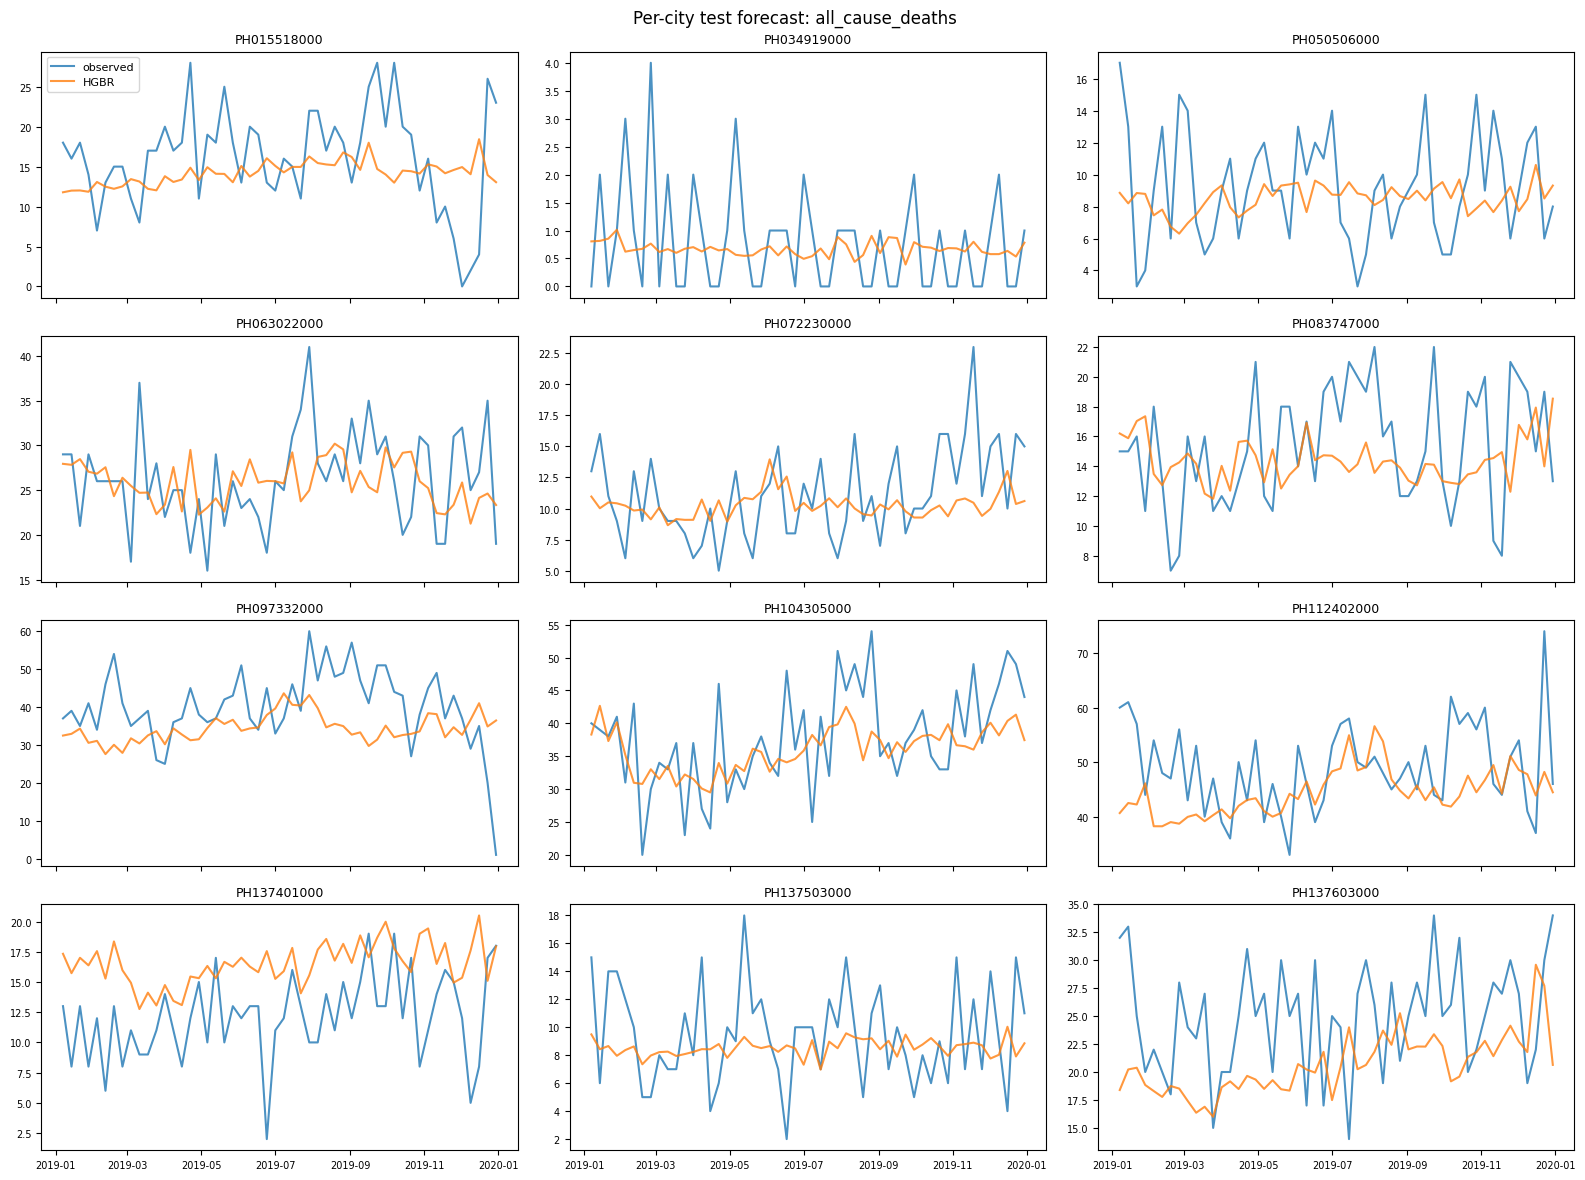

In [3]:
for outcome, pred in [("all_cause_cases", "pred_cases"), ("all_cause_deaths", "pred_deaths")]:
    cities = sorted(test["adm3_pcode"].unique())
    nrows = (len(cities) + 2) // 3
    fig, axes = plt.subplots(nrows, 3, figsize=(16, 3 * nrows), sharex=True)
    axes = axes.flatten()
    for ax, c in zip(axes, cities):
        g = test[test["adm3_pcode"] == c].sort_values("date")
        ax.plot(g["date"], g[outcome], label="observed", alpha=0.8)
        ax.plot(g["date"], g[pred],    label="HGBR",     alpha=0.8)
        ax.set_title(c, fontsize=9)
        ax.tick_params(labelsize=7)
    for ax in axes[len(cities):]:
        ax.axis("off")
    axes[0].legend(fontsize=8)
    fig.suptitle(f"Per-city test forecast: {outcome}")
    plt.tight_layout()
    plt.show()

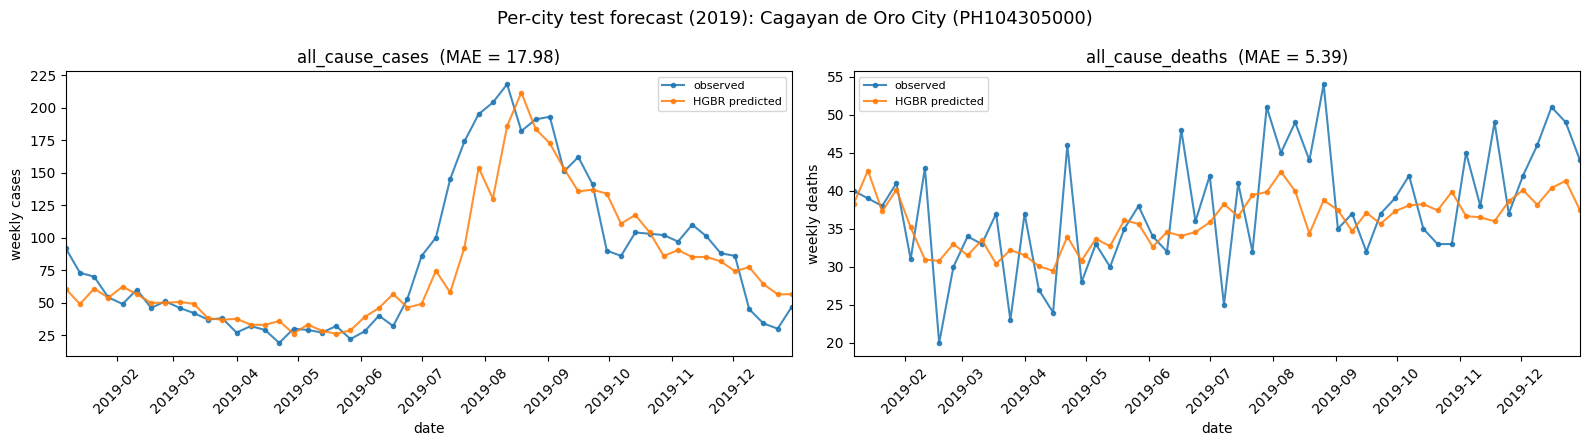

In [8]:
# Single-city test forecast: cases and deaths side by side.
# Set `city` to any adm3_pcode in the 2019 test set (see the list printed below).
city = "PH104305000"

available = sorted(test["adm3_pcode"].unique())
if city not in available:
    raise ValueError(f"{city!r} not in the test set. Available cities: {available}")

city_label = city_names.get(city, city)  # human-readable name, fall back to the pcode
g = test[test["adm3_pcode"] == city].sort_values("date")

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
panels = [
    ("all_cause_cases",  "pred_cases",  "cases"),
    ("all_cause_deaths", "pred_deaths", "deaths"),
]
for ax, (obs, pred, label) in zip(axes, panels):
    ax.plot(g["date"], g[obs],  label="observed",        marker="o", markersize=3, alpha=0.85)
    ax.plot(g["date"], g[pred], label="HGBR predicted",  marker="o", markersize=3, alpha=0.85)
    mae = mean_absolute_error(g[obs], g[pred])
    ax.set_title(f"all_cause_{label}  (MAE = {mae:.2f})")
    ax.set_xlabel("date")
    ax.set_ylabel(f"weekly {label}")
    ax.set_xlim(g["date"].min(), g["date"].max())
    ax.legend(fontsize=8)
    ax.tick_params(axis="x", labelrotation=45)

fig.suptitle(f"Per-city test forecast (2019): {city_label} ({city})", fontsize=13)
plt.tight_layout()
plt.show()

## 2. Residual diagnostics

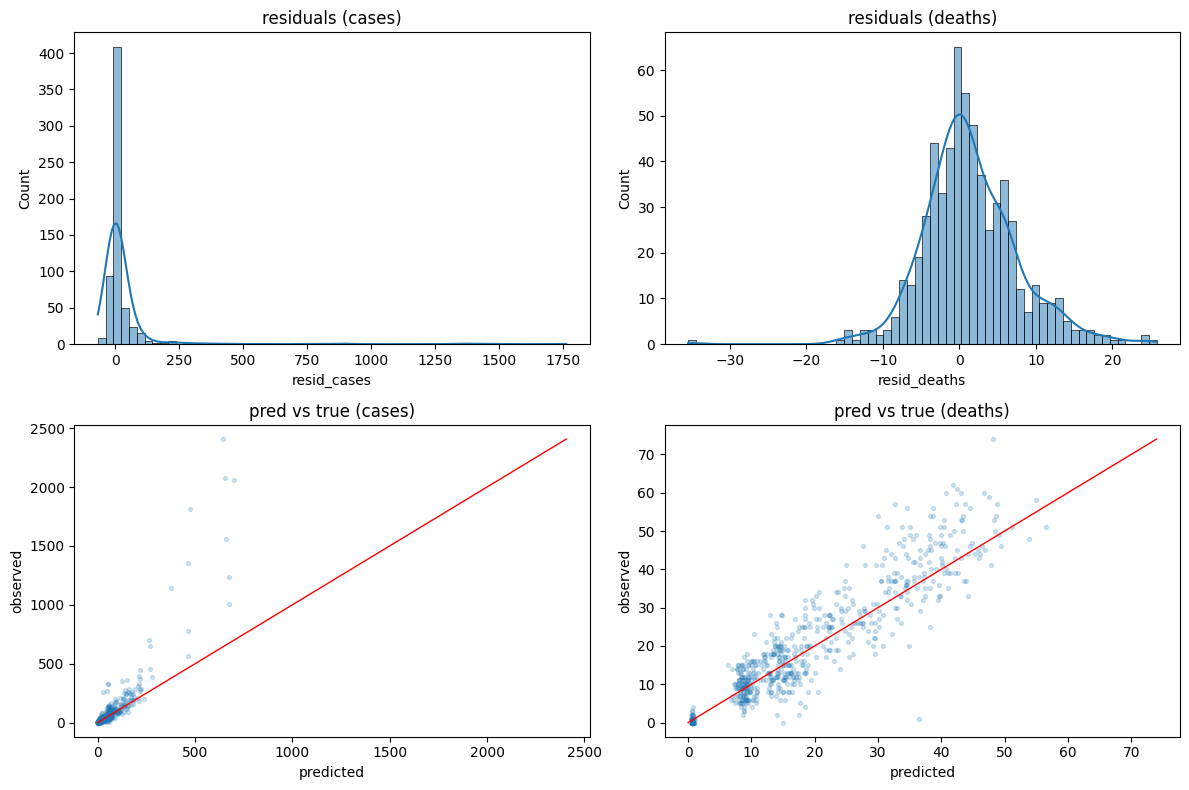

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (col, title) in zip(axes[0], [("resid_cases", "residuals (cases)"), ("resid_deaths", "residuals (deaths)")]):
    sns.histplot(test[col], bins=60, ax=ax, kde=True)
    ax.set_title(title)
for ax, (pred, true, title) in zip(axes[1], [("pred_cases", "all_cause_cases", "pred vs true (cases)"), ("pred_deaths", "all_cause_deaths", "pred vs true (deaths)")]):
    ax.scatter(test[pred], test[true], alpha=0.2, s=8)
    lim = max(test[pred].max(), test[true].max())
    ax.plot([0, lim], [0, lim], color="red", linewidth=1)
    ax.set_xlabel("predicted")
    ax.set_ylabel("observed")
    ax.set_title(title)
plt.tight_layout()
plt.show()

## 3. SHAP global importance + top-N shortlist for the Streamlit UI

/Users/adonaisray.maclang/Desktop/morbidity-mortality-modelling/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


wrote /Users/adonaisray.maclang/Desktop/morbidity-mortality-modelling/data/output/models/shap_importance_cases.csv
wrote top_features_cases.json ( 15 features )


wrote /Users/adonaisray.maclang/Desktop/morbidity-mortality-modelling/data/output/models/shap_importance_deaths.csv
wrote top_features_deaths.json ( 15 features )


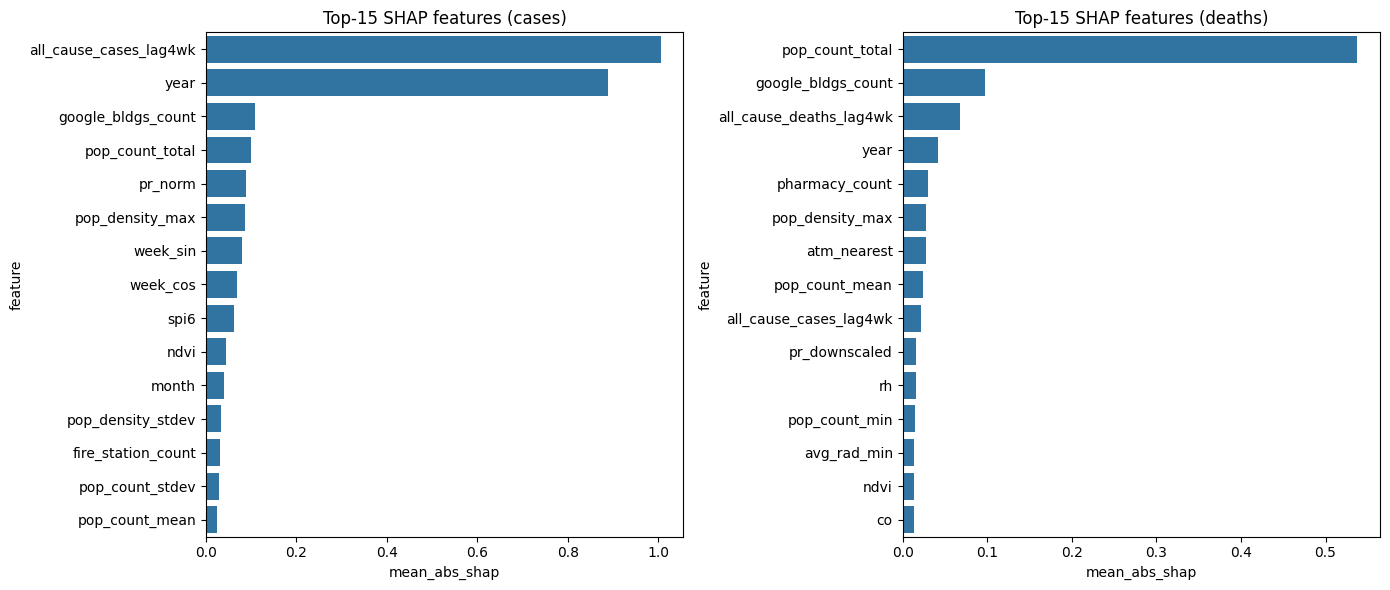

In [5]:
import shap

# Sample the test set to keep TreeExplainer fast and the UI artifact small.
sample = test[feature_cols].sample(min(2000, len(test)), random_state=42)

def shap_top_n(model, X, label, top_n=15):
    expl = shap.TreeExplainer(model)
    sv = expl.shap_values(X)
    mean_abs = np.abs(sv).mean(axis=0)
    imp = pd.DataFrame({"feature": X.columns, "mean_abs_shap": mean_abs}).sort_values("mean_abs_shap", ascending=False)
    out = OUT / f"shap_importance_{label}.csv"
    imp.to_csv(out, index=False)
    print("wrote", out)
    top = imp.head(top_n)["feature"].tolist()
    (OUT / f"top_features_{label}.json").write_text(json.dumps(top, indent=2))
    print("wrote top_features_" + label + ".json (", len(top), "features )")
    return imp

cases_imp  = shap_top_n(cases_model,  sample, "cases")
deaths_imp = shap_top_n(deaths_model, sample, "deaths")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, imp, label in zip(axes, [cases_imp, deaths_imp], ["cases", "deaths"]):
    sns.barplot(data=imp.head(15), x="mean_abs_shap", y="feature", ax=ax)
    ax.set_title(f"Top-15 SHAP features ({label})")
plt.tight_layout()
plt.show()

## 4. Per-city headline

In [6]:
headline = test.groupby("adm3_pcode").apply(
    lambda g: pd.Series({
        "n": len(g),
        "cases_obs_total": int(g["all_cause_cases"].sum()),
        "cases_pred_total": int(g["pred_cases"].sum()),
        "cases_mae": float(mean_absolute_error(g["all_cause_cases"], g["pred_cases"])),
        "deaths_obs_total": int(g["all_cause_deaths"].sum()),
        "deaths_pred_total": int(g["pred_deaths"].sum()),
        "deaths_mae": float(mean_absolute_error(g["all_cause_deaths"], g["pred_deaths"])),
    }),
    include_groups=False,
).reset_index()
headline

,adm3_pcode,n,cases_obs_total,cases_pred_total,cases_mae,deaths_obs_total,deaths_pred_total,deaths_mae
0,PH015518000,52.0,869.0,866.0,5.751407,839.0,738.0,5.582885
1,PH034919000,52.0,237.0,183.0,2.931189,40.0,34.0,0.757920
2,PH050506000,52.0,348.0,267.0,3.102109,480.0,443.0,3.053811
3,PH063022000,52.0,23432.0,10835.0,249.557033,1369.0,1345.0,4.371972
4,PH072230000,52.0,1339.0,1362.0,8.842185,579.0,534.0,2.942770
5,PH083747000,52.0,3051.0,1921.0,30.832421,796.0,748.0,3.409978
6,PH097332000,52.0,7641.0,5359.0,51.535470,2080.0,1790.0,9.346511
7,PH104305000,52.0,4323.0,4046.0,17.979960,1964.0,1872.0,5.386337
8,PH112402000,52.0,4325.0,4389.0,23.268999,2551.0,2312.0,6.963413
9,PH137401000,52.0,927.0,744.0,7.236056,627.0,857.0,4.743601


## 5. Summary verdict

On the **2019 test set** (`metrics.json["overall"]`), the four candidates — HGBR, LightGBM, lasso, ridge — land in a tight band; the two gradient-boosting models and Ridge are essentially neck-and-neck, and HGBR is kept as the persisted production model because the Streamlit UI + this notebook rely on SHAP `TreeExplainer`. Deaths are predicted well (R² ≈ 0.82); cases are harder (R² ≈ 0.55), driven by a few high-count city-weeks visible in the residual scatter above.

On the **2020+ stress set** (`metrics.json["stress_2020plus"]`) every model degrades — expected, since the COVID era is far outside the training distribution. Report the 2019 numbers as the headline and treat 2020+ as a robustness check, not a benchmark.

The top-N feature lists (`top_features_cases.json`, `top_features_deaths.json`) are what the Streamlit UI exposes as sliders -- everything else is filled with the per-city seasonal median.